In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/House_Rent_Dataset.csv")

In [3]:
df[["BHK", "Rent", "Size", "Bathroom"]].describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


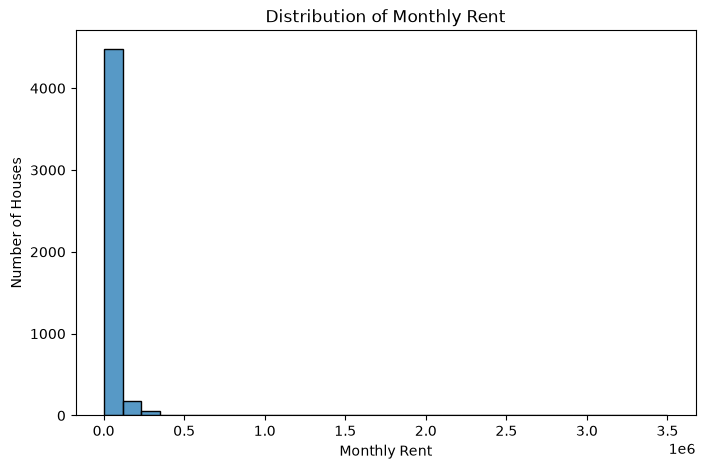

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Rent"], bins=30)

plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent")
plt.ylabel("Number of Houses")

plt.show()

In [6]:
df[["Rent", "BHK", "Size", "Bathroom", "City"]].sort_values(
    by="Rent", ascending=False
).head(10)

,Rent,BHK,Size,Bathroom,City
1837,3500000,3,2500,3,Bangalore
1001,1200000,4,5000,4,Mumbai
827,1000000,4,3064,4,Mumbai
1329,850000,4,3200,4,Mumbai
1459,700000,4,3200,4,Mumbai
1484,680000,4,1962,5,Mumbai
1319,650000,5,3000,5,Mumbai
1384,600000,5,4500,5,Mumbai
726,600000,4,2500,4,Mumbai
3656,600000,2,950,2,Chennai


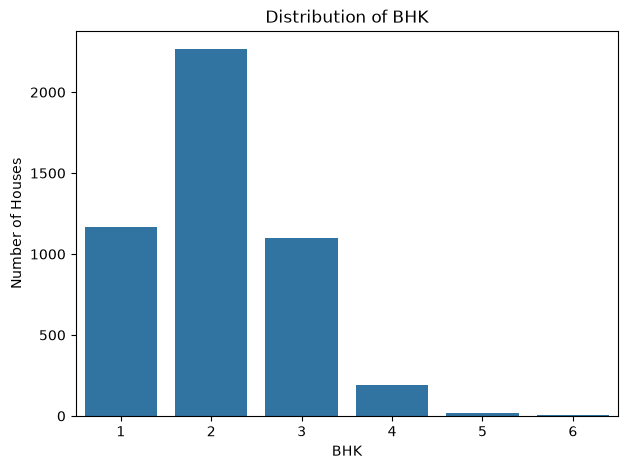

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="BHK")

plt.title("Distribution of BHK")
plt.xlabel("BHK")
plt.ylabel("Number of Houses")

plt.show()

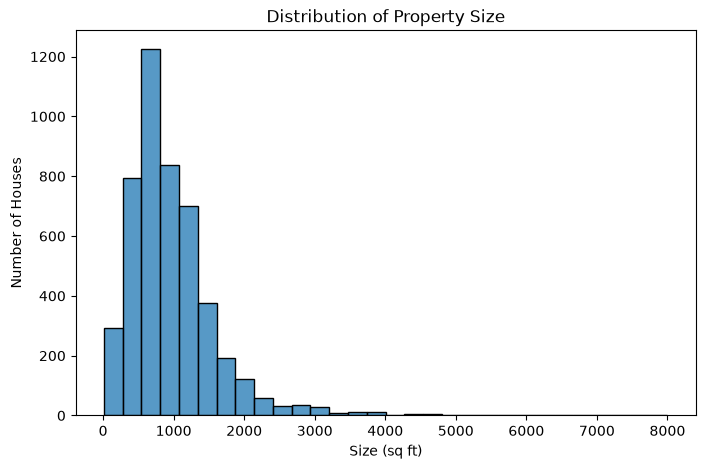

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Size"], bins=30)

plt.title("Distribution of Property Size")
plt.xlabel("Size (sq ft)")
plt.ylabel("Number of Houses")

plt.show()

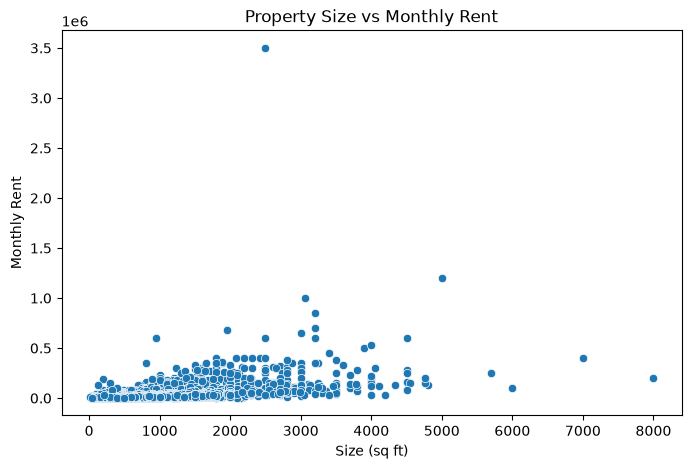

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Size", y="Rent")

plt.title("Property Size vs Monthly Rent")
plt.xlabel("Size (sq ft)")
plt.ylabel("Monthly Rent")

plt.show()

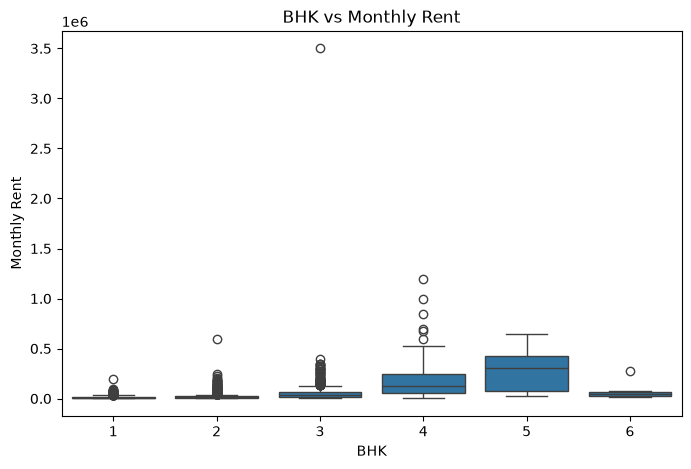

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="BHK", y="Rent")

plt.title("BHK vs Monthly Rent")
plt.xlabel("BHK")
plt.ylabel("Monthly Rent")

plt.show()

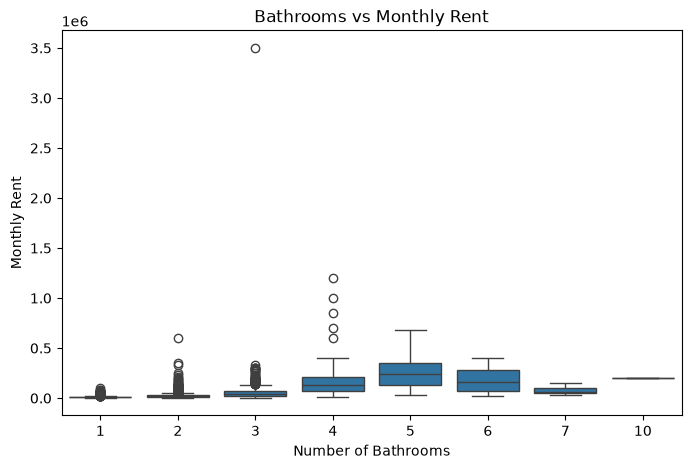

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Bathroom", y="Rent")

plt.title("Bathrooms vs Monthly Rent")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Monthly Rent")

plt.show()

In [12]:
avg_bathroom_rent = df.groupby("Bathroom")["Rent"].mean()

avg_bathroom_rent

Bathroom
1      11862.162144
2      25043.538193
3      63176.698264
4     167846.153846
5     252350.000000
6     177500.000000
7      81666.666667
10    200000.000000
Name: Rent, dtype: float64

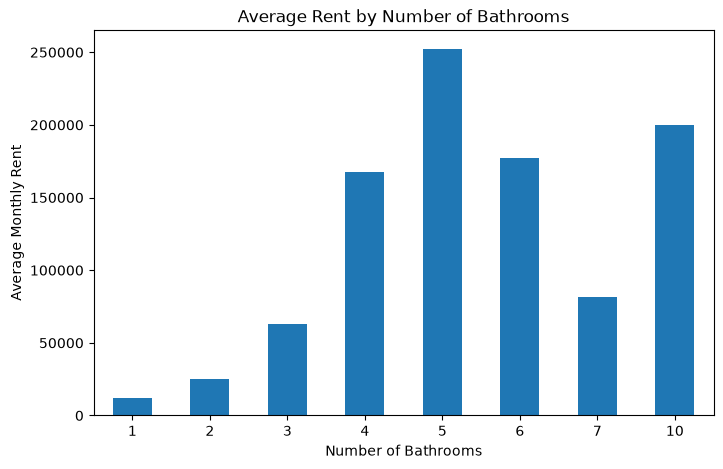

In [13]:
plt.figure(figsize=(8, 5))

avg_bathroom_rent.plot(kind="bar")

plt.title("Average Rent by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Monthly Rent")

plt.xticks(rotation=0)
plt.show()

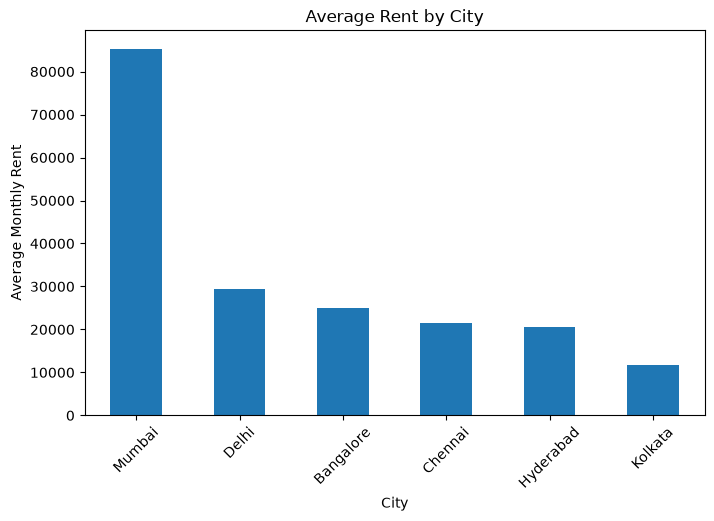

In [14]:
avg_city_rent = df.groupby("City")["Rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

avg_city_rent.plot(kind="bar")

plt.title("Average Rent by City")
plt.xlabel("City")
plt.ylabel("Average Monthly Rent")

plt.xticks(rotation=45)
plt.show()

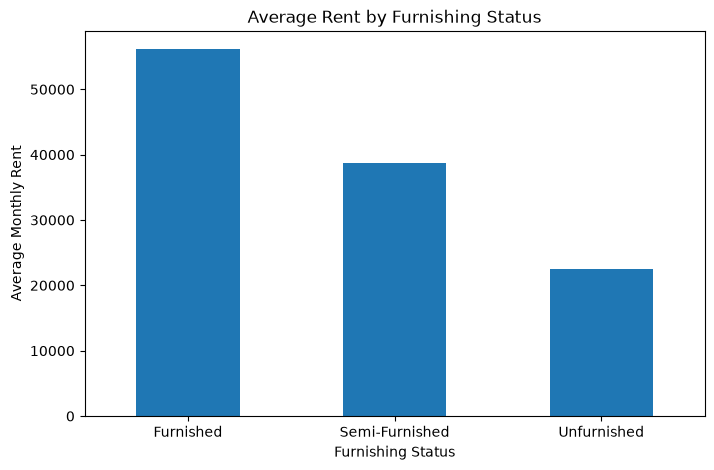

In [15]:
avg_furnishing_rent = df.groupby("Furnishing Status")["Rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

avg_furnishing_rent.plot(kind="bar")

plt.title("Average Rent by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Monthly Rent")

plt.xticks(rotation=0)
plt.show()

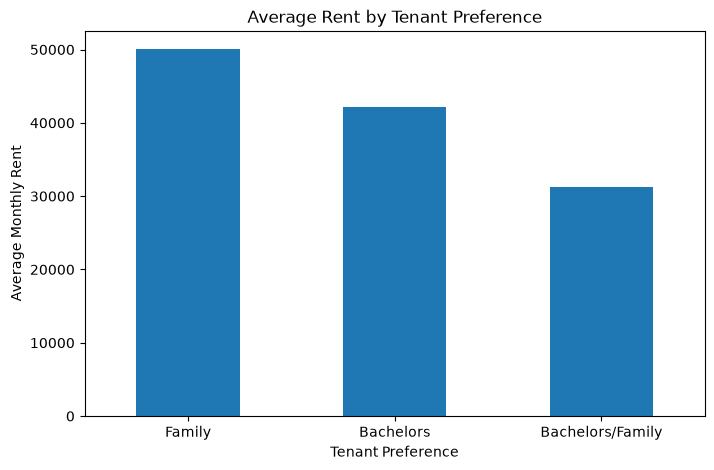

In [16]:
avg_tenant_rent = df.groupby("Tenant Preferred")["Rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

avg_tenant_rent.plot(kind="bar")

plt.title("Average Rent by Tenant Preference")
plt.xlabel("Tenant Preference")
plt.ylabel("Average Monthly Rent")

plt.xticks(rotation=0)
plt.show()

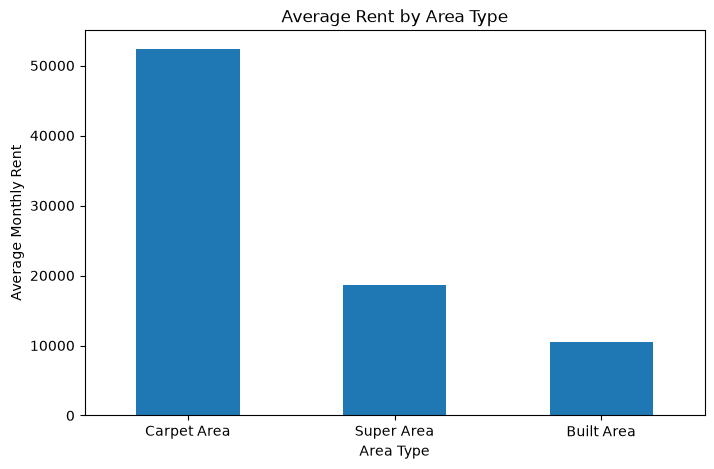

In [17]:
avg_area_type_rent = df.groupby("Area Type")["Rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

avg_area_type_rent.plot(kind="bar")

plt.title("Average Rent by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Average Monthly Rent")

plt.xticks(rotation=0)
plt.show()

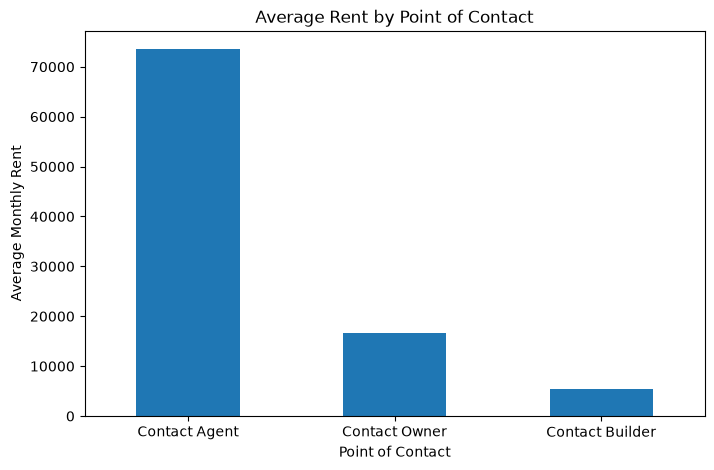

In [18]:
avg_contact_rent = df.groupby("Point of Contact")["Rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

avg_contact_rent.plot(kind="bar")

plt.title("Average Rent by Point of Contact")
plt.xlabel("Point of Contact")
plt.ylabel("Average Monthly Rent")

plt.xticks(rotation=0)
plt.show()

In [19]:
df["Floor"].value_counts().head(20)

Floor
1 out of 2         379
Ground out of 2    350
2 out of 3         312
2 out of 4         308
1 out of 3         293
3 out of 4         239
Ground out of 3    209
1 out of 4         200
Ground out of 1    195
1 out of 1         134
2 out of 2         132
Ground out of 4    115
2 out of 5         106
3 out of 3          96
1 out of 5          87
4 out of 5          86
3 out of 5          84
4 out of 4          73
3 out of 7          32
5 out of 7          32
Name: count, dtype: int64

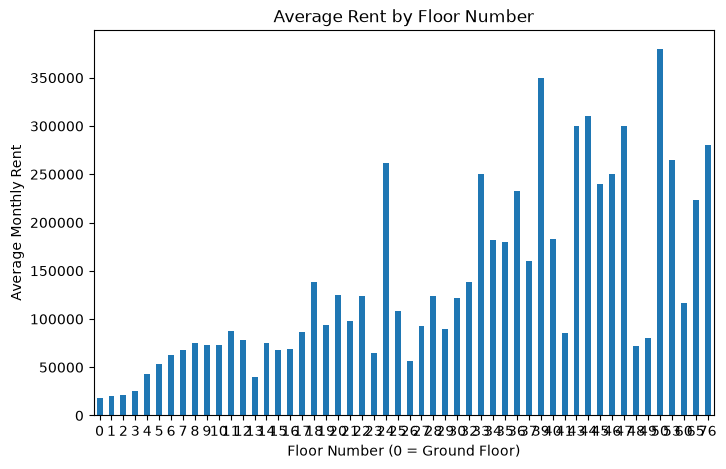

In [20]:
floor_rent = df.copy()

floor_rent["Floor_Number"] = floor_rent["Floor"].str.extract(r"(\d+)")
floor_rent["Floor_Number"] = floor_rent["Floor_Number"].fillna(0).astype(int)

avg_floor_rent = floor_rent.groupby("Floor_Number")["Rent"].mean()

plt.figure(figsize=(8, 5))
avg_floor_rent.plot(kind="bar")

plt.title("Average Rent by Floor Number")
plt.xlabel("Floor Number (0 = Ground Floor)")
plt.ylabel("Average Monthly Rent")
plt.xticks(rotation=0)
plt.show()

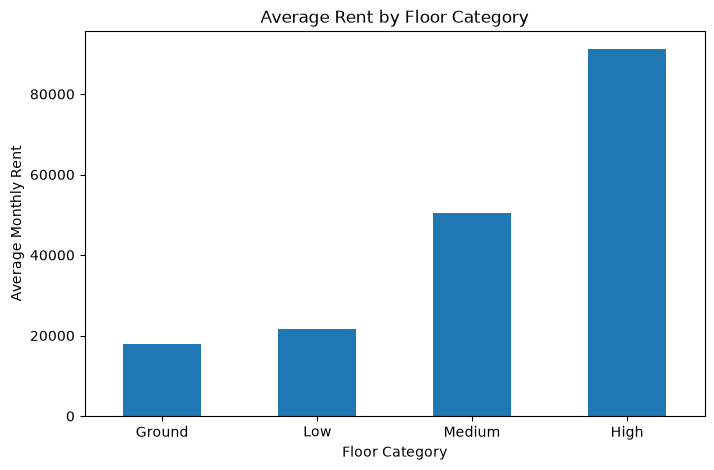

In [21]:
floor_rent["Floor_Category"] = pd.cut(
    floor_rent["Floor_Number"],
    bins=[-1, 0, 3, 7, float("inf")],
    labels=["Ground", "Low", "Medium", "High"]
)

avg_floor_category_rent = (
    floor_rent.groupby("Floor_Category", observed=False)["Rent"]
    .mean()
)

plt.figure(figsize=(8, 5))
avg_floor_category_rent.plot(kind="bar")

plt.title("Average Rent by Floor Category")
plt.xlabel("Floor Category")
plt.ylabel("Average Monthly Rent")
plt.xticks(rotation=0)
plt.show()

In [22]:
print("Unique localities:", df["Area Locality"].nunique())

print("\nTop 15 localities:")
print(df["Area Locality"].value_counts().head(15))

Unique localities: 2235

Top 15 localities:
Area Locality
Bandra West                37
Gachibowli                 29
Electronic City            24
Velachery                  22
Miyapur, NH 9              22
Madipakkam                 20
Chembur                    19
K R Puram                  19
Laxmi Nagar                19
Kondapur                   18
Medavakkam                 17
Iyyappanthangal            17
Banjara Hills, NH 9        17
Salt Lake City Sector 2    16
Sholinganallur             16
Name: count, dtype: int64


In [23]:
print("Earliest listing:", df["Posted On"].min())
print("Latest listing:", df["Posted On"].max())

Earliest listing: 01-05-2022
Latest listing: 31-05-2022


Rent: The rent distribution is strongly right-skewed. Most properties have relatively low rents, while a small number of properties have extremely high rents.
Size: Most properties are around 500–1,500 sq ft. Rent generally increases as property size increases, but size alone does not determine rent.
BHK: 2 BHK properties are the most common. Higher BHK properties generally tend to have higher rents.
Bathrooms: Properties with more bathrooms generally show higher average rents, although categories with very few properties can be less reliable.
City: Rent varies substantially by city. Mumbai has the highest average rent among the cities in the dataset, showing that location is an important factor.
Furnishing: Furnished properties generally have higher rents than semi-furnished and unfurnished properties.
Tenant Preference: Average rent differs between tenant-preference groups, indicating that this feature may contain useful information.
Area Type: Average rent varies across Carpet Area, Super Area, and Built Area categories.
Point of Contact: Agent-listed properties have a noticeably higher average rent than owner- and builder-listed properties.
Floor: Average rent generally increases from ground/low floors toward higher-floor categories, although very high floors have fewer observations.
Area Locality: There are 2,235 unique localities, so locality is highly diverse and cannot be handled efficiently with simple one-hot encoding.